# Results quick‑walk notebook

This notebook reads outputs from `results_cv/` created by `experiments_cv.py` and produces quick summary tables & figures.

In [13]:
# Imports
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image

plt.rcParams['figure.figsize'] = (8,4)
plt.rcParams['image.cmap'] = 'viridis'


In [14]:
# Robust helpers (replacement for earlier helpers)
def load_csv_if_exists(path, index_col=0):
    """
    Robust CSV loader: tries to read with index_col=0 then coerces numeric columns.
    Returns a numeric DataFrame if possible, otherwise the original DataFrame or None if missing.
    """
    if not os.path.exists(path):
        return None
    try:
        df = pd.read_csv(path, index_col=index_col)
    except Exception:
        df = pd.read_csv(path)
    # Attempt to coerce to numeric (for all columns)
    df_numeric = df.apply(pd.to_numeric, errors='coerce')
    # If coercion produced all-NaN, fallback to reading without index_col and coerce
    if df_numeric.isna().all(axis=0).all():
        df = pd.read_csv(path)
        df_numeric = df.apply(pd.to_numeric, errors='coerce')
    # Drop entirely-NaN columns/rows
    df_numeric = df_numeric.dropna(axis=1, how='all')
    df_numeric = df_numeric.dropna(axis=0, how='all')
    if df_numeric.shape[0] == 0 or df_numeric.shape[1] == 0:
        return df  # return original for debugging
    return df_numeric

def plot_heatmap_from_df(df, title=None, xticklabels=None, yticklabels=None):
    if not np.issubdtype(df.values.dtype, np.number):
        df = df.apply(pd.to_numeric, errors='coerce')
    if df.isna().all(axis=None):
        raise ValueError('DataFrame contains no numeric data to plot.')
    arr = df.values.astype(float)
    fig, ax = plt.subplots(figsize=(8,4))
    im = ax.imshow(arr, aspect='auto')
    ax.set_title(title or '')
    if xticklabels is not None:
        ax.set_xticks(np.arange(len(xticklabels)))
        ax.set_xticklabels(xticklabels, rotation=45)
    else:
        try:
            ax.set_xticks(np.arange(arr.shape[1]))
            ax.set_xticklabels(df.columns.tolist(), rotation=45)
        except Exception:
            pass
    if yticklabels is not None:
        ax.set_yticks(np.arange(len(yticklabels)))
        ax.set_yticklabels(yticklabels)
    else:
        try:
            ax.set_yticks(np.arange(arr.shape[0]))
            ax.set_yticklabels(df.index.tolist())
        except Exception:
            pass
    plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    plt.tight_layout()
    plt.show()
    return fig

def inspect_csv(path):
    print('Path:', path)
    if not os.path.exists(path):
        print('File not found.'); return
    print('\nRead with index_col=0:')
    try:
        df0 = pd.read_csv(path, index_col=0)
        print(df0.dtypes)
        display(df0.head())
    except Exception as e:
        print('Failed:', e)
    print('\nRead without index_col:')
    df1 = pd.read_csv(path)
    print(df1.dtypes)
    display(df1.head())
    print('\nCoercing to numeric:')
    df1_num = df1.apply(pd.to_numeric, errors='coerce')
    print(df1_num.dtypes)
    display(df1_num.head())


In [15]:
# 1) Show quick/full summary files if present
RESULTS_DIR = 'results_cv'
if not os.path.exists(RESULTS_DIR):
    raise FileNotFoundError(f"{RESULTS_DIR} not found — run experiments_cv.py first and ensure outputs are saved here.")
pastlen_dirs = sorted([d for d in os.listdir(RESULTS_DIR) if d.startswith('pastlen_')])
print('Found pastlen folders:', pastlen_dirs)

quick_path = os.path.join(RESULTS_DIR, 'quick_stage_summary.csv')
full_path = os.path.join(RESULTS_DIR, 'full_stage_summary.csv')
if os.path.exists(quick_path):
    print('\nQuick stage summary:')
    display(pd.read_csv(quick_path))
else:
    print('\nquick_stage_summary.csv not found')
if os.path.exists(full_path):
    print('\nFull stage summary:')
    display(pd.read_csv(full_path))
else:
    print('\nfull_stage_summary.csv not found')


Found pastlen folders: ['pastlen_120', 'pastlen_20', 'pastlen_60']

Quick stage summary:


,past_len,pooled_dual_quick,n_folds
0,20,0.452348,4
1,60,0.507935,4
2,120,0.386154,4



Full stage summary:


,past_len,pooled_dual
0,120,0.162387
1,20,0.156965
2,60,0.152117


## 2) Per past_len: aggregated loss matrix, bootstrap table, and calibration


--- pastlen_120 ---
Aggregated dual loss matrix:


,H=1,H=2,H=3,H=5,H=10
q=0.1,0.096436,0.103234,0.109513,0.114263,0.124972
q=0.5,0.216475,0.239780,0.253685,0.269930,0.299020
q=0.9,0.103413,0.111702,0.119806,0.127725,0.145850


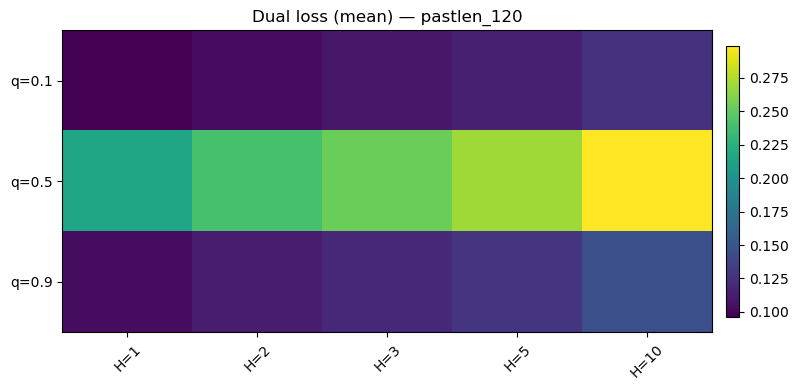


agg_qh_bootstrap_results (top rows):


,past_len,q,h,price_ci_lo,price_ci_hi,price_pval,concat_ci_lo,concat_ci_hi,concat_pval,har_ci_lo,har_ci_hi,har_pval
0,120,0.1,1,0.000052,-0.002048,0.0660,-0.000972,-0.005367,0.0075,0.005676,0.004888,1.0000
1,120,0.1,2,0.002402,0.000636,0.6425,0.002602,-0.001704,0.2080,0.008580,0.007640,1.0000
2,120,0.1,3,0.003327,0.001587,0.8200,0.004208,0.000190,0.5195,0.005104,0.003795,0.9875
3,120,0.1,5,0.001981,0.001413,0.6945,0.002417,0.001056,0.5970,0.002445,0.002798,0.8900
4,120,0.1,10,-0.004541,-0.001239,0.1730,-0.003585,-0.000582,0.2400,0.001178,-0.002435,0.2775
5,120,0.5,1,0.003591,0.005378,0.9445,0.003688,0.001241,0.5710,0.013485,0.014294,1.0000
6,120,0.5,2,0.005619,0.009179,0.9930,0.008638,0.007690,0.9900,0.010017,0.012863,1.0000
7,120,0.5,3,0.004069,0.008897,0.9675,0.007807,0.008302,0.9930,0.005009,0.010286,0.9810
8,120,0.5,5,0.003770,0.012817,0.9410,0.008844,0.012571,0.9925,0.002902,0.010037,0.8835
9,120,0.5,10,0.002466,0.015357,0.8180,0.006646,0.017694,0.9260,-0.005437,-0.000118,0.2705



Aggregated empirical coverage (dual):


,H=1,H=2,H=3,H=5,H=10
q=0.1,0.071803,0.078244,0.081823,0.077290,0.078006
q=0.5,0.443702,0.438216,0.435830,0.426765,0.416269
q=0.9,0.893368,0.883588,0.880487,0.873330,0.855677


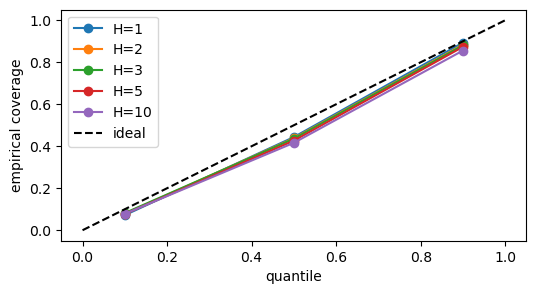


--- pastlen_20 ---
Aggregated dual loss matrix:


,H=1,H=2,H=3,H=5,H=10
q=0.1,0.093722,0.099292,0.104865,0.109410,0.120898
q=0.5,0.208478,0.228786,0.244009,0.258355,0.290954
q=0.9,0.102076,0.109736,0.117740,0.124531,0.141630


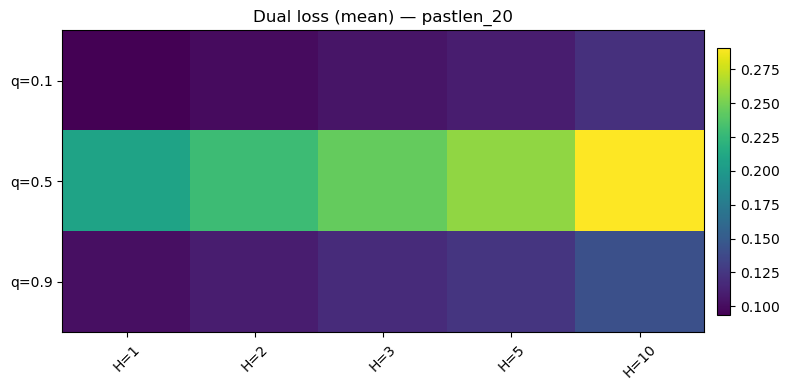


agg_qh_bootstrap_results (top rows):


,past_len,q,h,price_ci_lo,price_ci_hi,price_pval,concat_ci_lo,concat_ci_hi,concat_pval,har_ci_lo,har_ci_hi,har_pval
0,20,0.1,1,-0.008870,-0.011693,0.0000,-0.002766,-0.004863,0.0010,0.003808,0.001325,0.9865
1,20,0.1,2,-0.006346,-0.009239,0.0000,-0.001652,-0.003604,0.0085,0.003920,0.002072,0.9765
2,20,0.1,3,-0.006258,-0.009327,0.0000,-0.002137,-0.003815,0.0020,0.000697,-0.001190,0.2795
3,20,0.1,5,-0.006456,-0.008318,0.0000,-0.002424,-0.003336,0.0025,-0.002355,-0.004599,0.0025
4,20,0.1,10,-0.008861,-0.007038,0.0000,-0.008210,-0.005588,0.0055,-0.004795,-0.005760,0.0005
5,20,0.5,1,-0.014051,-0.017851,0.0000,-0.005315,-0.005886,0.0000,0.002570,0.000958,0.8935
6,20,0.5,2,-0.014124,-0.016855,0.0000,-0.004129,-0.003988,0.0015,-0.001417,-0.003190,0.0775
7,20,0.5,3,-0.011707,-0.014786,0.0000,-0.001649,-0.002463,0.0355,-0.002581,-0.004155,0.0250
8,20,0.5,5,-0.013816,-0.015184,0.0000,-0.002480,-0.001830,0.1465,-0.005942,-0.006607,0.0205
9,20,0.5,10,-0.012558,-0.010848,0.0005,-0.001786,0.000930,0.4820,-0.014488,-0.014735,0.0000



Aggregated empirical coverage (dual):


,H=1,H=2,H=3,H=5,H=10
q=0.1,0.074042,0.073389,0.072953,0.069904,0.076002
q=0.5,0.458188,0.446211,0.436193,0.431402,0.416376
q=0.9,0.903310,0.895906,0.892422,0.887631,0.876307


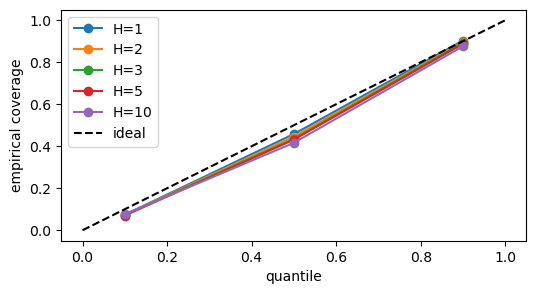


--- pastlen_60 ---
Aggregated dual loss matrix:


,H=1,H=2,H=3,H=5,H=10
q=0.1,0.091814,0.097840,0.103480,0.107932,0.119279
q=0.5,0.205062,0.223077,0.235413,0.248239,0.275587
q=0.9,0.100511,0.106966,0.113635,0.118962,0.133953


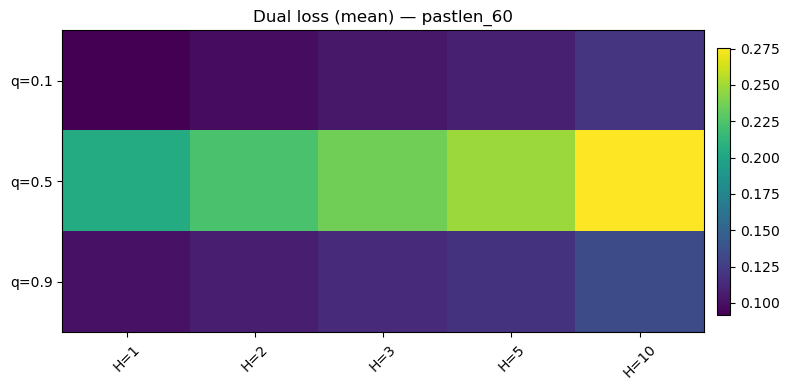


agg_qh_bootstrap_results (top rows):


,past_len,q,h,price_ci_lo,price_ci_hi,price_pval,concat_ci_lo,concat_ci_hi,concat_pval,har_ci_lo,har_ci_hi,har_pval
0,60,0.1,1,-0.014546,-0.013225,0.0000,-0.007769,-0.004304,0.0000,-0.000355,0.000130,0.6080
1,60,0.1,2,-0.010562,-0.010745,0.0000,-0.003761,-0.001494,0.0835,0.001367,0.001495,0.8255
2,60,0.1,3,-0.009348,-0.009072,0.0000,-0.002382,0.000487,0.3290,-0.002304,-0.002560,0.1455
3,60,0.1,5,-0.008508,-0.008879,0.0000,-0.001141,0.000700,0.3895,-0.003993,-0.005504,0.0110
4,60,0.1,10,-0.008363,-0.012119,0.0005,-0.000177,-0.002650,0.3525,-0.005460,-0.008046,0.0050
5,60,0.5,1,-0.027494,-0.029231,0.0000,-0.007617,-0.006167,0.0130,-0.001692,-0.002985,0.3540
6,60,0.5,2,-0.026504,-0.026257,0.0000,-0.006411,-0.005095,0.0385,-0.007192,-0.009270,0.0005
7,60,0.5,3,-0.026490,-0.027746,0.0000,-0.005689,-0.006454,0.0560,-0.011551,-0.012969,0.0000
8,60,0.5,5,-0.027868,-0.030558,0.0000,-0.006194,-0.006852,0.1410,-0.016270,-0.019263,0.0000
9,60,0.5,10,-0.028840,-0.034163,0.0000,-0.006890,-0.014141,0.1970,-0.030468,-0.033303,0.0000



Aggregated empirical coverage (dual):


,H=1,H=2,H=3,H=5,H=10
q=0.1,0.084838,0.086417,0.084612,0.082581,0.080776
q=0.5,0.500451,0.487139,0.466381,0.459161,0.436597
q=0.9,0.912681,0.905912,0.891245,0.888764,0.877482


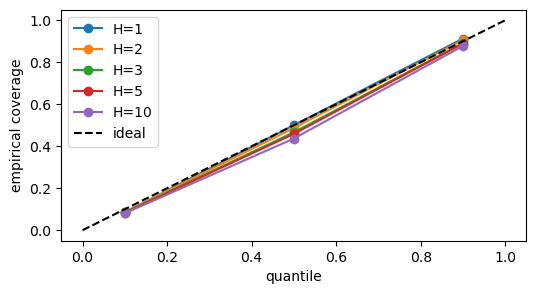

In [22]:
for d in pastlen_dirs:
    folder = os.path.join(RESULTS_DIR, d)
    print('\n---', d, '---')
    agg_loss_csv = os.path.join(folder, 'agg_dual_loss_matrix_mean.csv')
    agg_qh_csv = os.path.join(folder, 'agg_qh_bootstrap_results.csv')
    agg_cov_csv = os.path.join(folder, 'agg_dual_coverage_mean.csv')
    print('Aggregated dual loss matrix:')
    df_loss = load_csv_if_exists(agg_loss_csv)
    if df_loss is not None:
        display(df_loss)
        try:
            plot_heatmap_from_df(df_loss, title=f"Dual loss (mean) — {d}", xticklabels=list(df_loss.columns), yticklabels=list(df_loss.index))
        except Exception as e:
            print('Plotting failed:', e)
    else:
        print('  missing', agg_loss_csv)

    print('\nagg_qh_bootstrap_results (top rows):')
    df_qh = load_csv_if_exists(agg_qh_csv, index_col=None)
    if df_qh is not None:
        display(df_qh.head(10))
    else:
        print('  missing', agg_qh_csv)

    print('\nAggregated empirical coverage (dual):')
    df_cov = load_csv_if_exists(agg_cov_csv)
    if df_cov is not None:
        display(df_cov)
        try:
            cov = df_cov.values
            qs = [float(s.split('=')[1]) for s in df_cov.index]
            fig, ax = plt.subplots(figsize=(6,3))
            for i in range(cov.shape[1]):
                ax.plot(qs, cov[:, i], marker='o', label=f'{df_cov.columns[i]}')
            ax.plot([0,1],[0,1],'k--', label='ideal')
            ax.set_xlabel('quantile'); ax.set_ylabel('empirical coverage'); ax.legend()
            plt.show()
        except Exception as e:
            print('Calibration plot failed:', e)
    else:
        print('  missing', agg_cov_csv)


## 3) Per-asset pooled losses and boxplot (if available)


Per-asset pooled losses for pastlen_120


,asset,pooled_dual
0,SPY,0.162214
1,XLE,0.155439
2,XLF,0.174444
3,XLK,0.157451


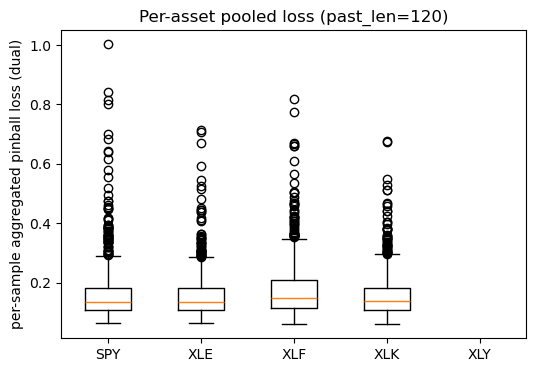


Per-asset pooled losses for pastlen_20


,asset,pooled_dual
0,SPY,0.155150
1,XLE,0.150917
2,XLF,0.164677
3,XLK,0.157117


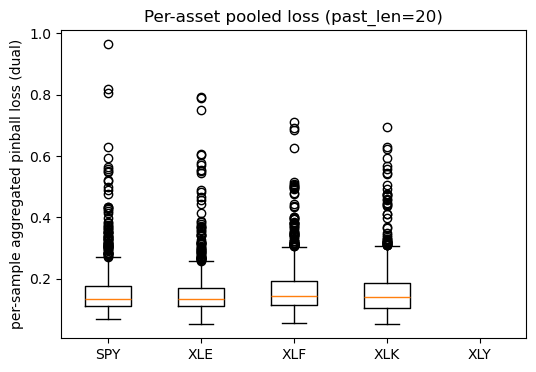


Per-asset pooled losses for pastlen_60


,asset,pooled_dual
0,SPY,0.150510
1,XLE,0.153910
2,XLF,0.159111
3,XLK,0.144936


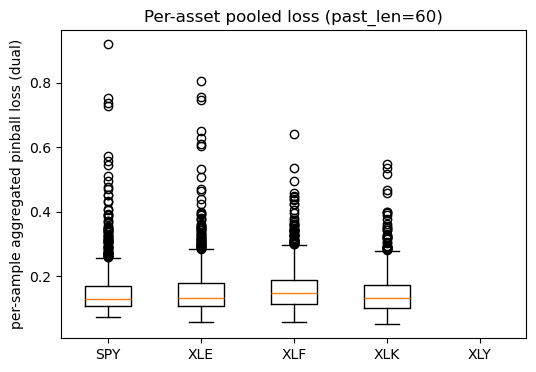

In [17]:
for d in pastlen_dirs:
    folder = os.path.join(RESULTS_DIR, d)
    paf = os.path.join(folder, 'per_asset_pooled_dual.csv')
    if os.path.exists(paf):
        print('\nPer-asset pooled losses for', d)
        dfp = pd.read_csv(paf)
        display(dfp)
        bp = os.path.join(folder, 'per_asset_boxplot_dual.png')
        if os.path.exists(bp):
            display(Image(bp))
        else:
            fig, ax = plt.subplots(figsize=(6,4))
            ax.bar(dfp['asset'], dfp['pooled_dual'])
            ax.set_title(f'Per-asset pooled dual loss — {d}'); plt.xticks(rotation=45); plt.show()
    else:
        print('\nNo per-asset pooled file for', d)


## 4) Pooled comparison across past_len candidates

,past_len,pooled_dual
0,120,0.162387
1,20,0.156965
2,60,0.152117


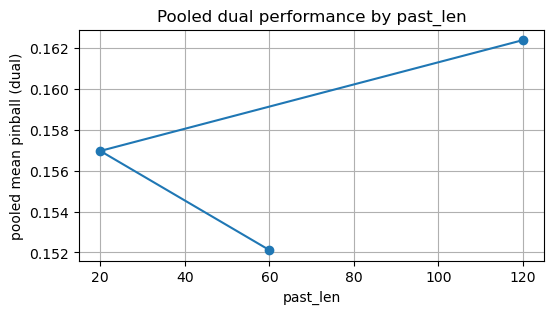

In [18]:
summary_csv = os.path.join(ROOT_RESULTS if 'ROOT_RESULTS' in globals() else RESULTS_DIR, 'full_stage_summary.csv')
if os.path.exists(summary_csv):
    s = pd.read_csv(summary_csv)
    display(s)
    plt.figure(figsize=(6,3))
    plt.plot(s['past_len'], s['pooled_dual'], marker='o')
    plt.xlabel('past_len'); plt.ylabel('pooled mean pinball (dual)'); plt.title('Pooled dual performance by past_len')
    plt.grid(True); plt.show()
else:
    print('full_stage_summary.csv not found; if you ran quick stage only, check quick_stage_summary.csv')


## 5) Event-level attention images (if produced)
Displays event attention PNGs saved by the pipeline (files named like `event_attn_YYYY-MM-DD.png`).


Event attention images for pastlen_120
 - results_cv/pastlen_120/event_attn_2020-03-17.png


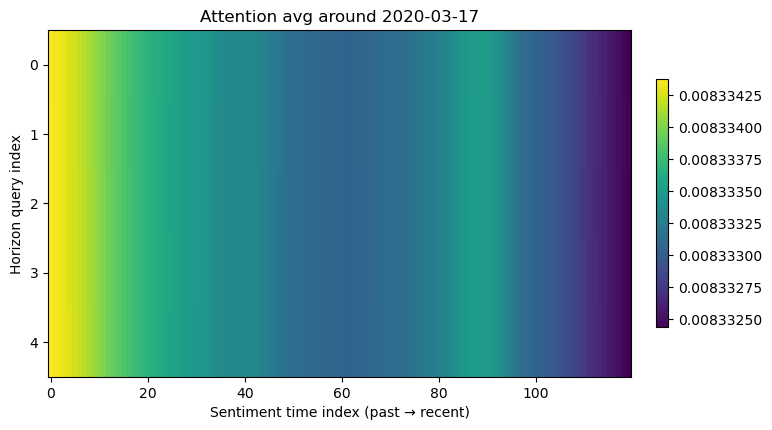

 - results_cv/pastlen_120/event_attn_2020-03-16.png


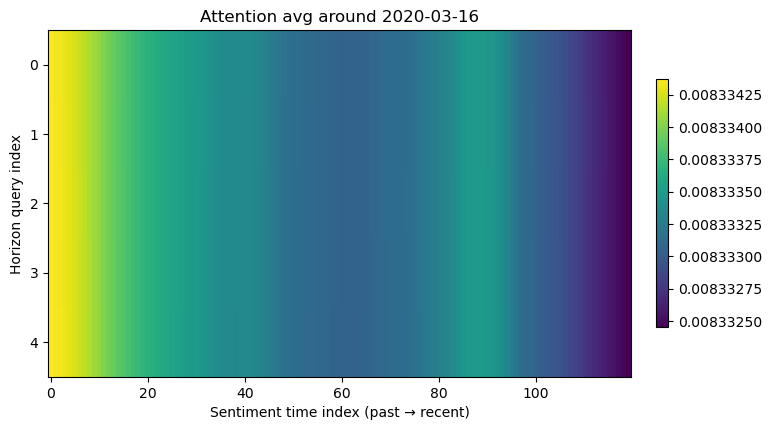

 - results_cv/pastlen_120/event_attn_2020-03-12.png


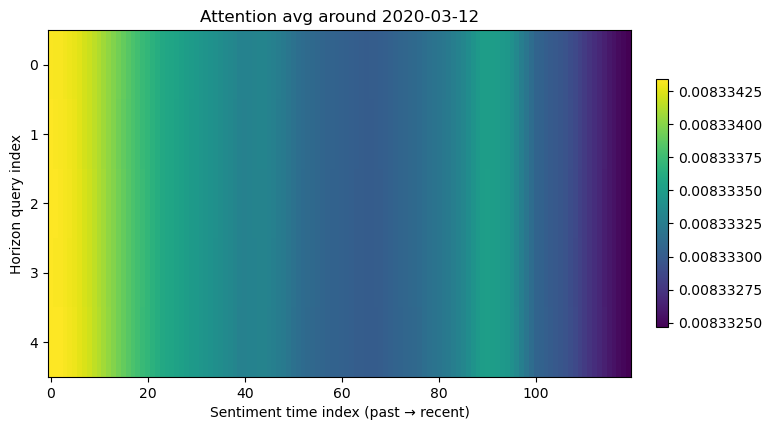

 - results_cv/pastlen_120/event_attn_timeseries_2020-03-17.png


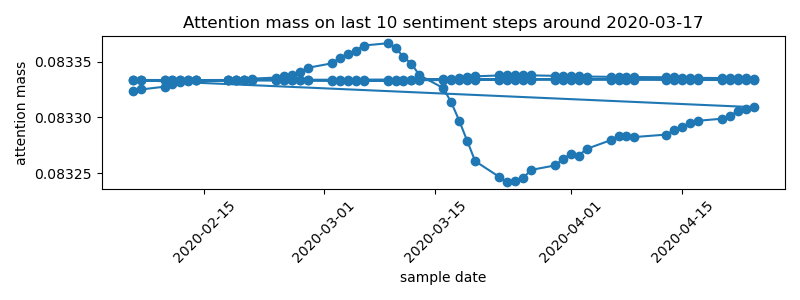

 - results_cv/pastlen_120/event_attn_timeseries_2020-03-16.png


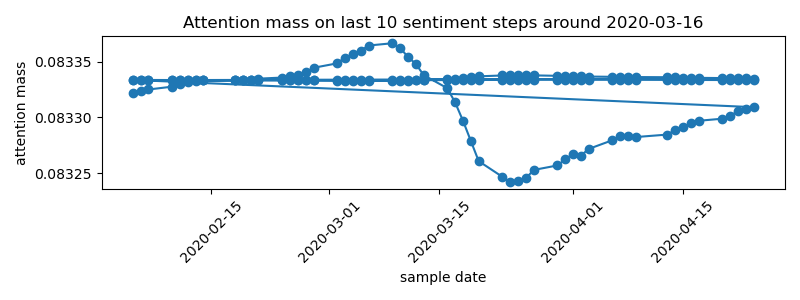

 - results_cv/pastlen_120/event_attn_timeseries_2020-03-12.png


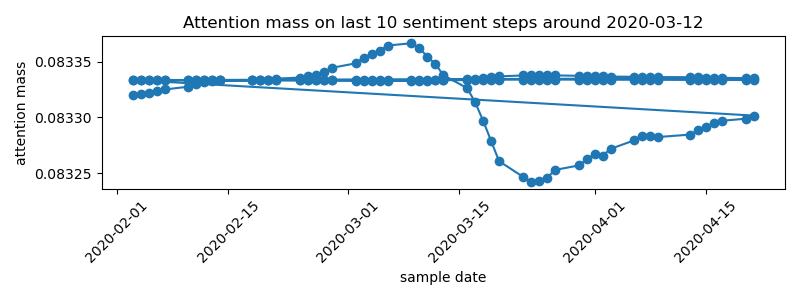

 - results_cv/pastlen_120/event_attn_timeseries_2020-03-23.png


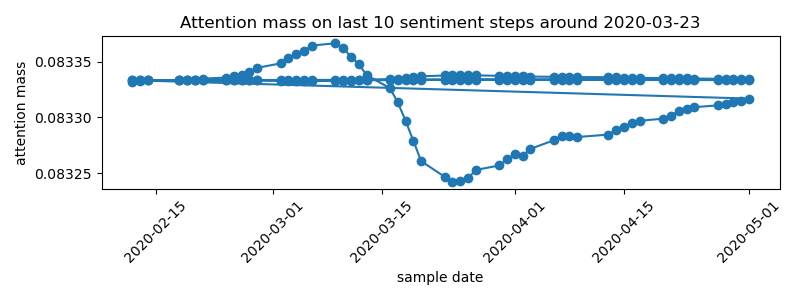

 - results_cv/pastlen_120/event_attn_timeseries_2020-03-19.png


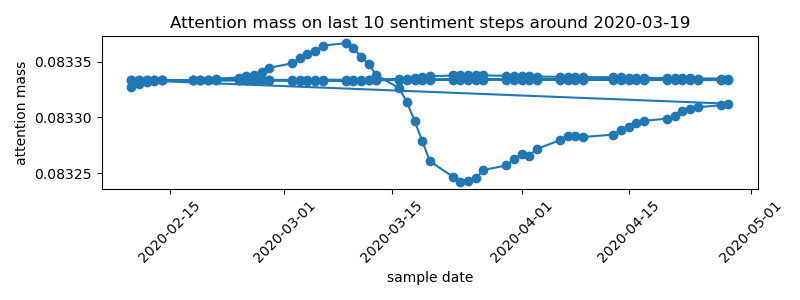

 - results_cv/pastlen_120/event_attn_2020-03-23.png


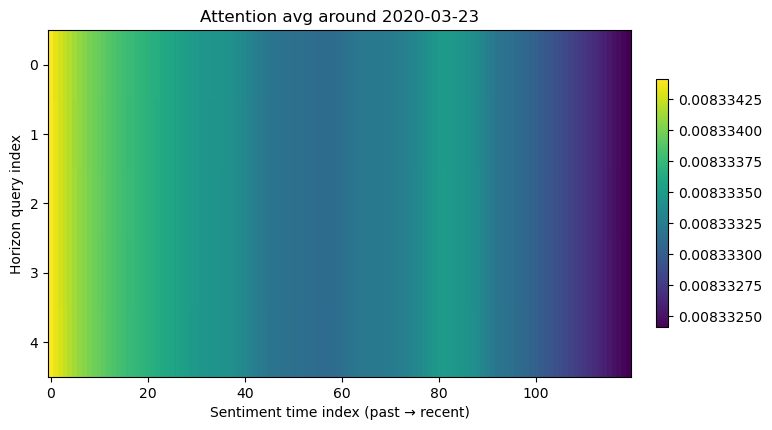

 - results_cv/pastlen_120/event_attn_2020-03-19.png


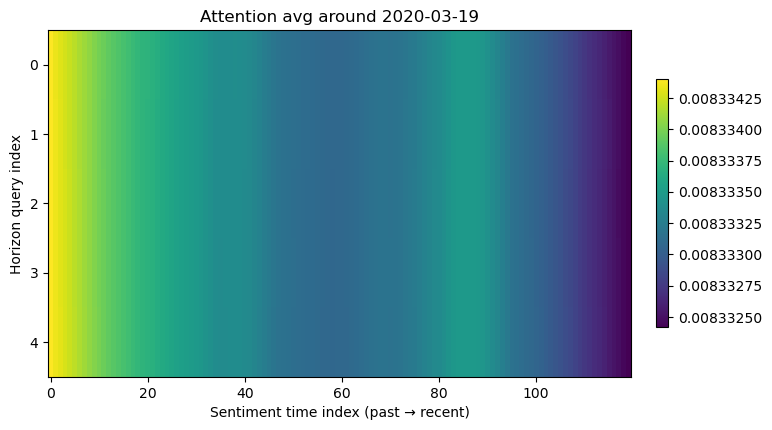


Event attention images for pastlen_20
 - results_cv/pastlen_20/event_attn_2020-03-17.png


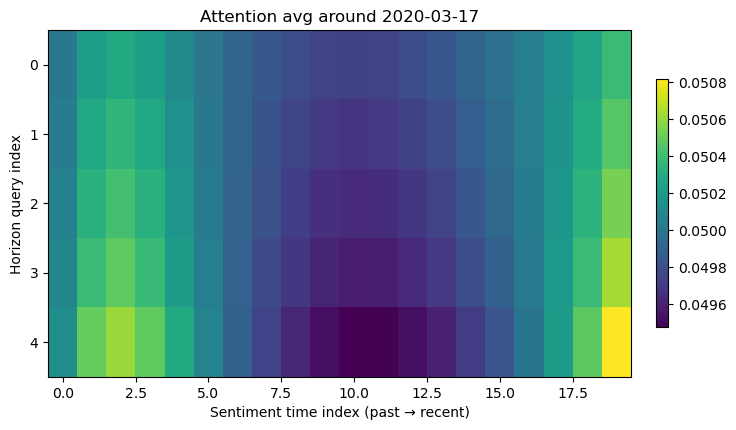

 - results_cv/pastlen_20/event_attn_2020-03-16.png


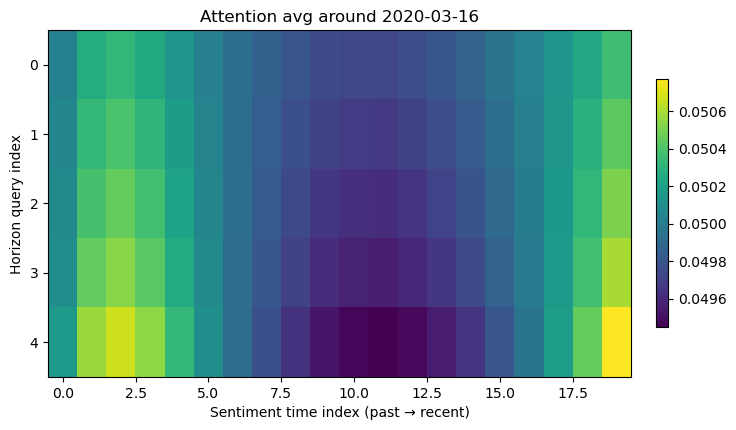

 - results_cv/pastlen_20/event_attn_2020-03-12.png


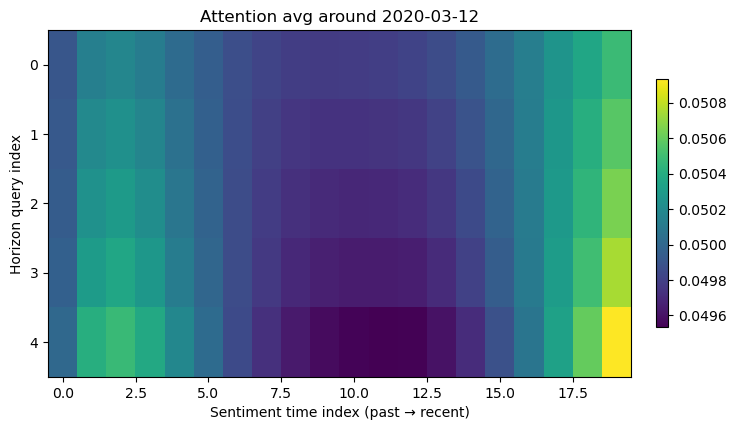

 - results_cv/pastlen_20/event_attn_timeseries_2020-03-17.png


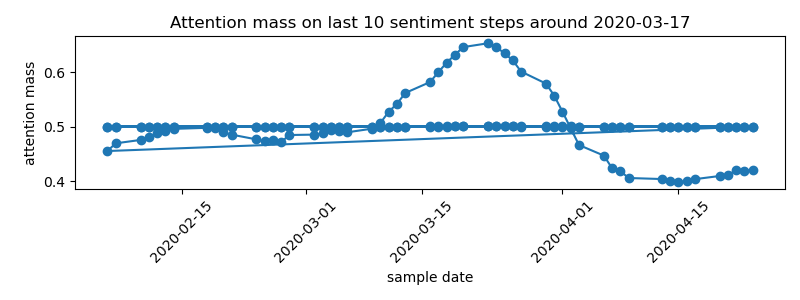

 - results_cv/pastlen_20/event_attn_timeseries_2020-03-16.png


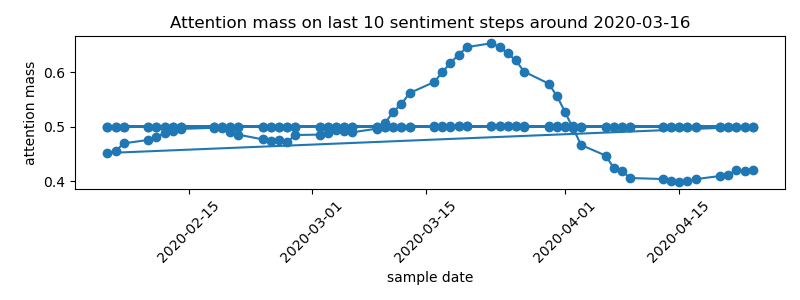

 - results_cv/pastlen_20/event_attn_timeseries_2020-03-12.png


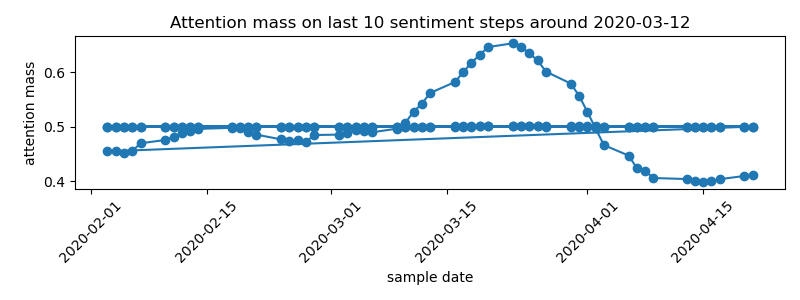

 - results_cv/pastlen_20/event_attn_timeseries_2020-03-23.png


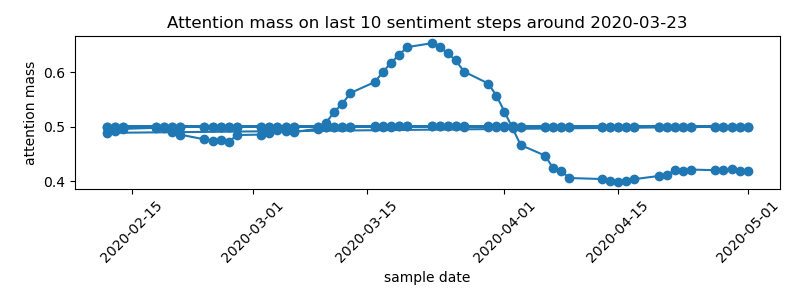

 - results_cv/pastlen_20/event_attn_timeseries_2020-03-19.png


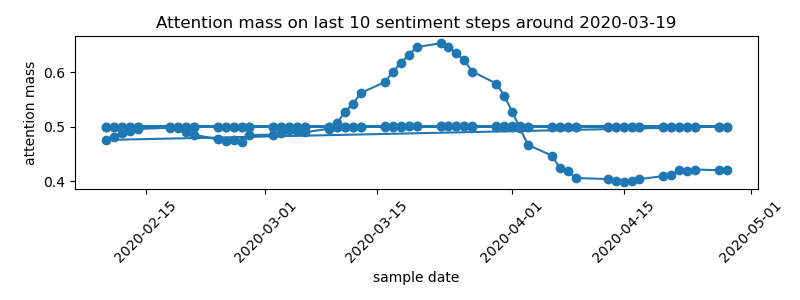

 - results_cv/pastlen_20/event_attn_2020-03-23.png


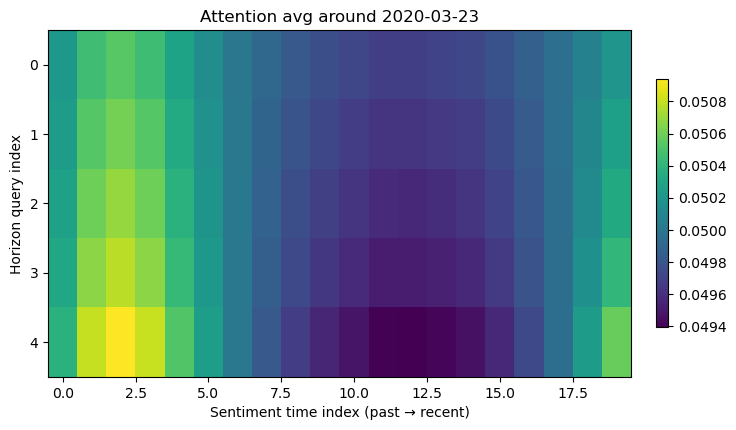

 - results_cv/pastlen_20/event_attn_2020-03-19.png


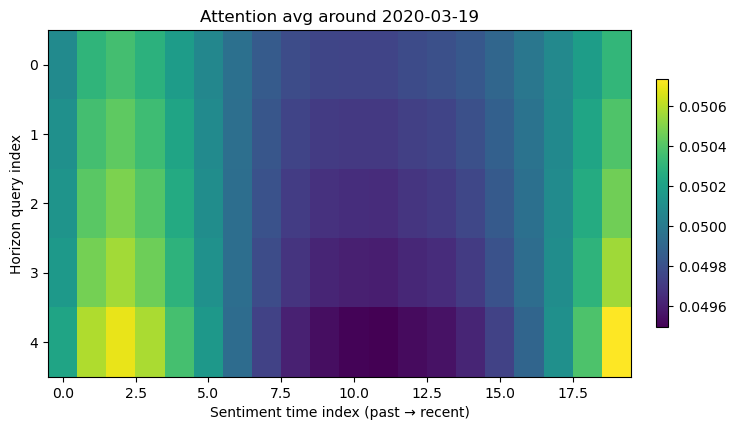


Event attention images for pastlen_60
 - results_cv/pastlen_60/event_attn_2020-03-17.png


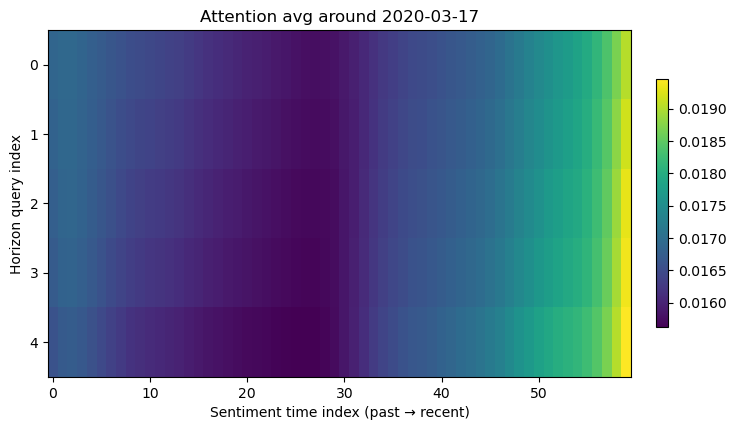

 - results_cv/pastlen_60/event_attn_2020-03-16.png


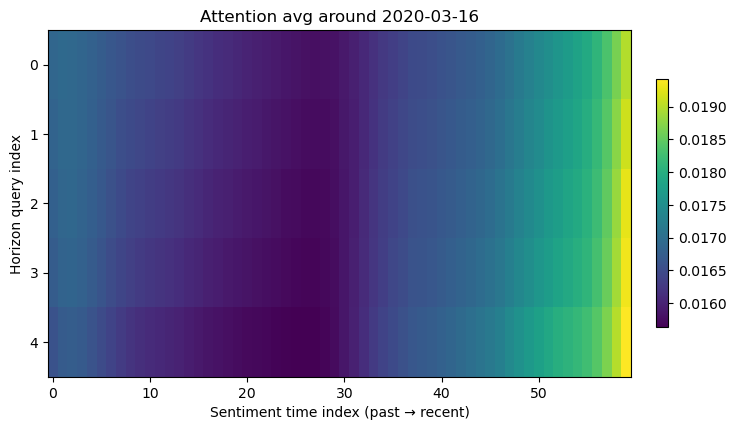

 - results_cv/pastlen_60/event_attn_2020-03-12.png


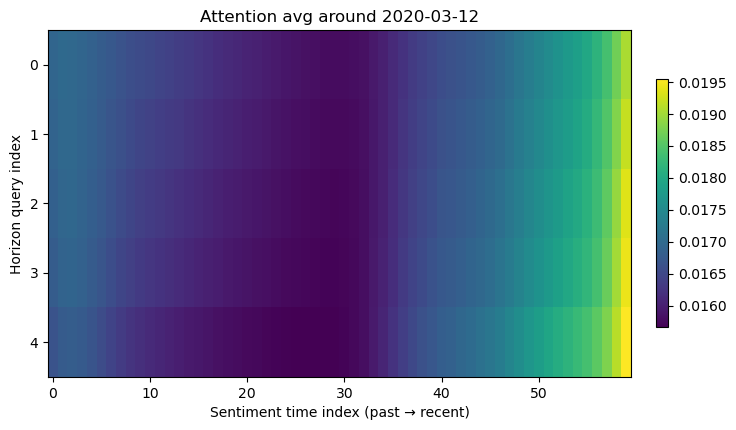

 - results_cv/pastlen_60/event_attn_timeseries_2020-03-17.png


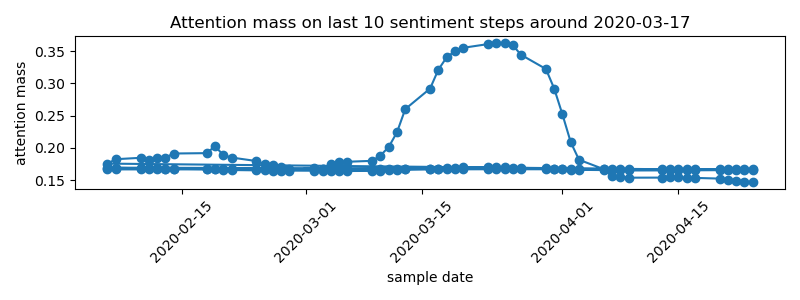

 - results_cv/pastlen_60/event_attn_timeseries_2020-03-16.png


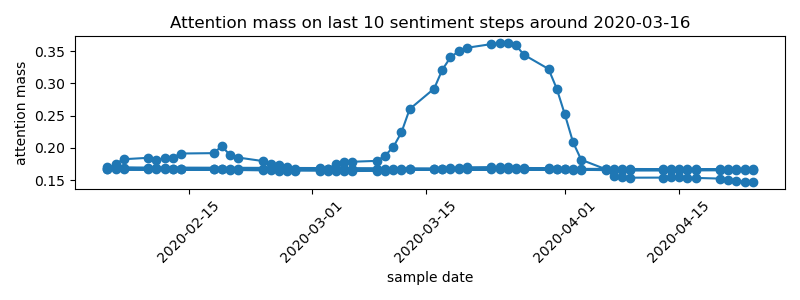

 - results_cv/pastlen_60/event_attn_timeseries_2020-03-12.png


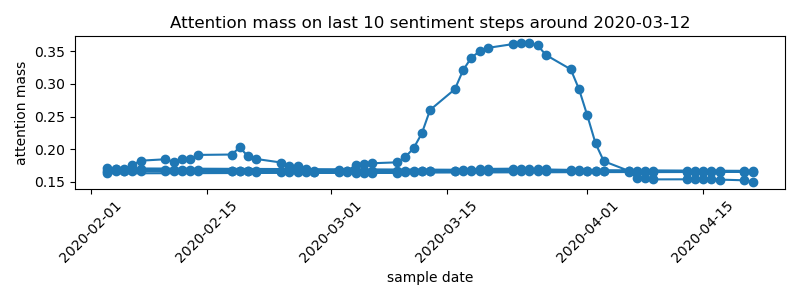

 - results_cv/pastlen_60/event_attn_timeseries_2020-03-23.png


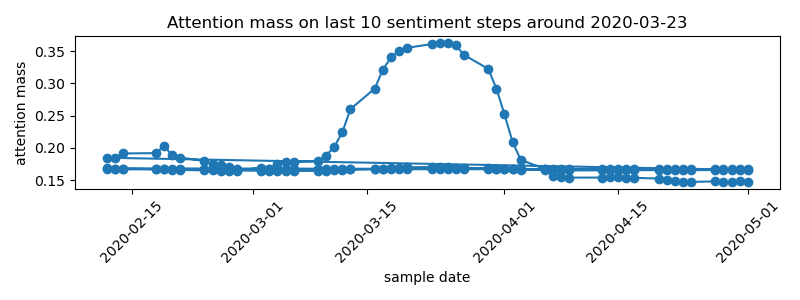

 - results_cv/pastlen_60/event_attn_timeseries_2020-03-19.png


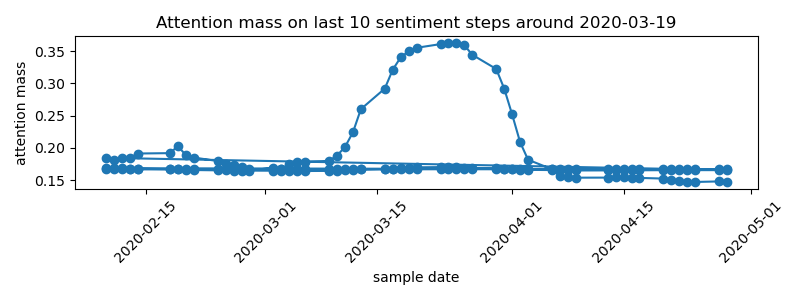

 - results_cv/pastlen_60/event_attn_2020-03-23.png


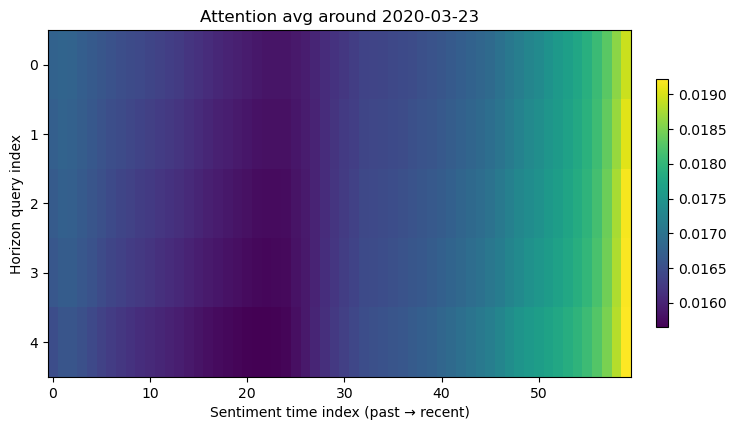

 - results_cv/pastlen_60/event_attn_2020-03-19.png


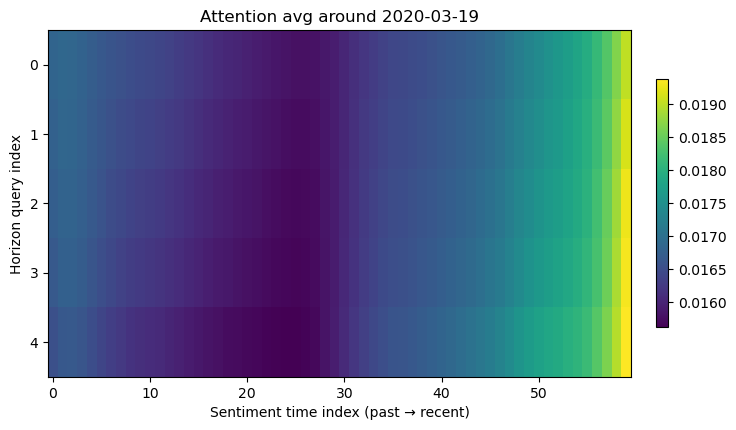

In [19]:
for d in pastlen_dirs:
    folder = os.path.join(RESULTS_DIR, d)
    imgs = glob.glob(os.path.join(folder, '**', 'event_attn_*.png'), recursive=True)
    if len(imgs) == 0:
        print('\nNo event attention images found for', d)
        continue
    print('\nEvent attention images for', d)
    for imf in imgs:
        print(' -', imf)
        display(Image(imf))


## 6) DM statistics and bootstrap p-values (per fold)
Aggregate any `dm_stats.csv` produced in fold folders.

In [20]:
dm_rows = []
for d in pastlen_dirs:
    fold_dirs = sorted(glob.glob(os.path.join(RESULTS_DIR, d, 'fold*')))
    for fd in fold_dirs:
        f = os.path.join(fd, 'dm_stats.csv')
        if os.path.exists(f):
            df = pd.read_csv(f)
            df['pastlen'] = d
            df['fold'] = os.path.basename(fd)
            dm_rows.append(df)
if len(dm_rows) > 0:
    dm_all = pd.concat(dm_rows, ignore_index=True)
    display(dm_all)
else:
    print('No dm_stats.csv files found in folds')


,dm_dp,dm_pval_dp,dm_dc,dm_pval_dc,dm_dh,dm_pval_dh,pastlen,fold
0,705.443126,0.0,430.234145,0.0,468.649657,0.0,pastlen_120,fold2
1,-77.082701,0.0,-141.581057,0.0,85.678752,0.0,pastlen_120,fold3
2,75.417183,0.0,101.519050,0.0,155.959313,0.0,pastlen_120,fold4
3,-167.450219,0.0,-74.246143,0.0,-113.746785,0.0,pastlen_120,fold5
4,-474.303282,0.0,117.213229,0.0,77.507769,0.0,pastlen_20,fold2
5,-285.203722,0.0,-117.052298,0.0,-105.670539,0.0,pastlen_20,fold3
6,-308.760659,0.0,-259.527202,0.0,-217.521945,0.0,pastlen_20,fold4
7,-332.250187,0.0,-278.561386,0.0,-254.152494,0.0,pastlen_20,fold5
8,-641.351661,0.0,381.565784,0.0,-87.768814,0.0,pastlen_60,fold2
9,-158.021677,0.0,-92.910587,0.0,32.843739,0.0,pastlen_60,fold3
